<a href="https://colab.research.google.com/github/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/blob/main/notebooks/01_exploracao_inicial_health_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predição do Valor de Sinistros em Seguro Saúde

## Estágio Supervisionado IV - Matemática Atuarial III

### Exploração inicial do conjunto de dados Health Insurance

**Objetivo:** realizar a exploração inicial do conjunto de dados *Health Insurance Data Set*, identificando sua estrutura, suas variáveis e as principais características dos dados que serão utilizados no desenvolvimento de um modelo preditivo para estimar o valor dos sinistros em seguro saúde.

## 1. Definição do problema

O custo dos sinistros é uma variável fundamental para a gestão de uma carteira de seguros, pois influencia diretamente a precificação, o planejamento financeiro e a avaliação dos riscos assumidos pela seguradora.

Neste projeto, pretende-se investigar se as características observadas dos segurados podem ser utilizadas para prever o valor dos sinistros em seguro saúde.

### Pergunta preditiva

**É possível estimar o valor do sinistro de um segurado a partir de suas características demográficas e de seus fatores de risco relacionados à saúde?**

### Variável resposta

A variável que se pretende prever é **`claim`**, que representa o valor do sinistro reclamado pelo segurado.

### Variáveis preditoras

As demais características disponíveis no conjunto de dados serão inicialmente consideradas como potenciais variáveis explicativas do valor dos sinistros. A relevância de cada uma delas será investigada posteriormente durante a análise exploratória e a modelagem.

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/refs/heads/main/data/healthinsurance.csv"

dados = pd.read_csv(url)

In [3]:
dados.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [4]:
dados.shape

(15000, 13)

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


In [6]:
dados.isnull().sum()

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


In [7]:
(dados.isnull().sum() / len(dados)) * 100

,0
age,2.640000
sex,0.000000
weight,0.000000
bmi,6.373333
hereditary_diseases,0.000000
no_of_dependents,0.000000
smoker,0.000000
city,0.000000
bloodpressure,0.000000
diabetes,0.000000


In [8]:
dados.isnull().any(axis=1).sum()

np.int64(1352)

In [9]:
dados[dados["age"].isnull() & dados["bmi"].isnull()].shape

(0, 13)

In [10]:
dados.duplicated().sum()

np.int64(1096)

In [11]:
dados[dados.duplicated(keep=False)].sort_values(
    by=list(dados.columns)
).head(20)

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
2005,18.0,female,40,24.8,NoDisease,0,0,Charleston,60,0,0,HouseKeeper,2203.7
2362,18.0,female,40,24.8,NoDisease,0,0,Charleston,60,0,0,HouseKeeper,2203.7
4078,18.0,female,44,26.3,NoDisease,0,0,Fargo,76,1,0,Labourer,2198.2
8072,18.0,female,44,26.3,NoDisease,0,0,Fargo,76,1,0,Labourer,2198.2
833,18.0,female,44,NaN,NoDisease,0,0,Charleston,96,1,0,Photographer,21344.9
6897,18.0,female,44,NaN,NoDisease,0,0,Charleston,96,1,0,Photographer,21344.9
1377,18.0,female,46,29.2,NoDisease,0,0,SantaRosa,64,1,1,FashionDesigner,7323.7
10350,18.0,female,46,29.2,NoDisease,0,0,SantaRosa,64,1,1,FashionDesigner,7323.7
9571,18.0,female,48,20.3,NoDisease,0,0,Nashville,60,1,0,HomeMakers,11482.6
12142,18.0,female,48,20.3,NoDisease,0,0,Nashville,60,1,0,HomeMakers,11482.6


In [12]:
dados.drop_duplicates().shape

(13904, 13)

### 1.1 Verificação inicial da qualidade dos dados

O conjunto de dados original possui **15.000 observações e 13 variáveis**.

A análise de valores ausentes identificou:

- **396 valores ausentes em `age`**, correspondentes a **2,64%** das observações;
- **956 valores ausentes em `bmi`**, correspondentes a aproximadamente **6,37%** das observações;
- não foram identificados valores ausentes nas demais variáveis;
- não existem registros em que `age` e `bmi` estejam simultaneamente ausentes.

No total, **1.352 observações apresentam pelo menos um valor ausente**, enquanto **13.648 observações estão completas em todas as variáveis**.

Também foram identificadas **1.096 linhas duplicadas** considerando conjuntamente as 13 variáveis do conjunto de dados. Caso as duplicidades sejam removidas, a base passa de 15.000 para **13.904 registros únicos**.

Nesta etapa exploratória, os valores ausentes e os registros duplicados foram apenas identificados. As decisões relativas ao tratamento dessas ocorrências serão realizadas posteriormente, durante a etapa de preparação dos dados para a modelagem.

In [13]:
dados.nunique()

,0
age,47
sex,2
weight,58
bmi,269
hereditary_diseases,10
no_of_dependents,6
smoker,2
city,91
bloodpressure,69
diabetes,2


In [14]:
print("sex:", dados["sex"].unique())
print("smoker:", dados["smoker"].unique())
print("diabetes:", dados["diabetes"].unique())
print("regular_ex:", dados["regular_ex"].unique())

sex: ['male' 'female']
smoker: [0 1]
diabetes: [0 1]
regular_ex: [0 1]


In [15]:
dados["hereditary_diseases"].unique()

array(['NoDisease', 'Epilepsy', 'EyeDisease', 'Alzheimer', 'Arthritis',
       'HeartDisease', 'Diabetes', 'Cancer', 'High BP', 'Obesity'],
      dtype=object)

In [16]:
dados["hereditary_diseases"].value_counts()

,count
hereditary_diseases,
NoDisease,13998
Diabetes,148
Alzheimer,144
Obesity,136
EyeDisease,123
Cancer,109
Arthritis,96
HeartDisease,93
Epilepsy,84


In [17]:
dados["diabetes"].value_counts()

,count
diabetes,
1,11655
0,3345


In [18]:
pd.crosstab(dados["hereditary_diseases"], dados["diabetes"])

diabetes,0,1
hereditary_diseases,,
Alzheimer,4,140
Arthritis,15,81
Cancer,6,103
Diabetes,6,142
Epilepsy,18,66
EyeDisease,19,104
HeartDisease,0,93
High BP,5,64
NoDisease,3248,10750


In [19]:
for variavel in ["smoker", "diabetes", "regular_ex"]:
    print(f"\n{variavel}")
    print(dados[variavel].value_counts())


smoker
smoker
0    12028
1     2972
Name: count, dtype: int64

diabetes
diabetes
1    11655
0     3345
Name: count, dtype: int64

regular_ex
regular_ex
0    11638
1     3362
Name: count, dtype: int64


In [20]:
dados["sex"].value_counts()

,count
sex,
female,7652
male,7348


In [21]:
dados["sex"].value_counts(normalize=True) * 100

,proportion
sex,
female,51.013333
male,48.986667


In [22]:
dados["city"].value_counts().head(10)

,count
city,
Nashville,302
NewOrleans,302
Charleston,298
Brimingham,298
Memphis,297
Charlotte,293
Louisville,293
Newport,280
Stamford,280


In [23]:
dados["city"].value_counts().tail(10)

,count
city,
SanFrancisco,103
Eureka,103
Huntsville,96
Macon,96
Orlando,96
Warwick,69
Syracuse,69
Trenton,69
York,69


In [24]:
sorted(dados["city"].unique())

['Atlanta',
 'AtlanticCity',
 'Bakersfield',
 'Baltimore',
 'Bloomington',
 'Boston',
 'Brimingham',
 'Brookings',
 'Buffalo',
 'Cambridge',
 'Canton',
 'Carlsbad',
 'Charleston',
 'Charlotte',
 'Chicago',
 'Cincinnati',
 'Cleveland',
 'Columbia',
 'Columbus',
 'Denver',
 'Escabana',
 'Eureka',
 'FallsCity',
 'Fargo',
 'Florence',
 'Fresno',
 'Georgia',
 'GrandForks',
 'Harrisburg',
 'Hartford',
 'Houston',
 'Huntsville',
 'Indianapolis',
 'IowaCity',
 'JeffersonCity',
 'KanasCity',
 'Kingman',
 'Kingsport',
 'Knoxville',
 'LasVegas',
 'Lincoln',
 'LosAngeles',
 'Louisville',
 'Lovelock',
 'Macon',
 'Mandan',
 'Marshall',
 'Memphis',
 'Mexicali',
 'Miami',
 'Minneapolis',
 'Minot',
 'Montrose',
 'Nashville',
 'NewOrleans',
 'NewYork',
 'Newport',
 'Oceanside',
 'Oklahoma',
 'Orlando',
 'Oxnard',
 'PanamaCity',
 'Pheonix',
 'Phildelphia',
 'Pittsburg',
 'Portland',
 'Prescott',
 'Providence',
 'Raleigh',
 'Reno',
 'Rochester',
 'Salina',
 'SanDeigo',
 'SanFrancisco',
 'SanJose',
 'SanLu

In [25]:
dados["job_title"].value_counts()

,count
job_title,
Student,1320
HomeMakers,972
Singer,744
Actor,720
FilmMaker,714
Dancer,693
HouseKeeper,667
Manager,602
Police,412


In [26]:
sorted(dados["job_title"].unique())

['Academician',
 'Accountant',
 'Actor',
 'Analyst',
 'Architect',
 'Beautician',
 'Blogger',
 'Buisnessman',
 'CA',
 'CEO',
 'Chef',
 'Clerks',
 'Dancer',
 'DataScientist',
 'DefencePersonnels',
 'Doctor',
 'Engineer',
 'Farmer',
 'FashionDesigner',
 'FilmDirector',
 'FilmMaker',
 'GovEmployee',
 'HomeMakers',
 'HouseKeeper',
 'ITProfessional',
 'Journalist',
 'Labourer',
 'Lawyer',
 'Manager',
 'Photographer',
 'Police',
 'Politician',
 'Singer',
 'Student',
 'Technician']

In [27]:
dados.describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,14604.000000,15000.000000,14044.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,39.547521,64.909600,30.266413,1.129733,0.198133,68.650133,0.777000,0.224133,13401.437620
std,14.015966,13.701935,6.122950,1.228469,0.398606,19.418515,0.416272,0.417024,12148.239619
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.700000,0.000000,0.000000,64.000000,1.000000,0.000000,4846.900000
50%,40.000000,63.000000,29.400000,1.000000,0.000000,71.000000,1.000000,0.000000,9545.650000
75%,52.000000,76.000000,34.400000,2.000000,0.000000,80.000000,1.000000,0.000000,16519.125000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


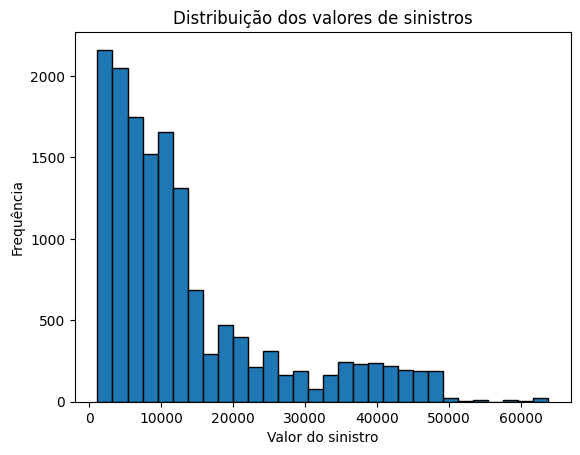

In [29]:
import matplotlib.pyplot as plt

plt.hist(dados["claim"], bins=30, edgecolor="black")
plt.xlabel("Valor do sinistro")
plt.ylabel("Frequência")
plt.title("Distribuição dos valores de sinistros")
plt.show()

In [30]:
dados["claim"].skew()

np.float64(1.4978293015042263)

In [31]:
Q1 = dados["claim"].quantile(0.25)
Q3 = dados["claim"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 4846.9
Q3: 16519.125
IQR: 11672.225


In [32]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Limite inferior: -12661.437500000002
Limite superior: 34027.4625


In [33]:
outliers_claim = dados[
    (dados["claim"] < limite_inferior) |
    (dados["claim"] > limite_superior)
]

outliers_claim.shape

(1642, 13)

In [34]:
len(outliers_claim) / len(dados) * 100

10.946666666666667

In [35]:
pd.crosstab(
    outliers_claim["smoker"],
    columns="Quantidade"
)

col_0,Quantidade
smoker,
0,48
1,1594


In [36]:
outliers_claim["smoker"].value_counts(normalize=True) * 100

,proportion
smoker,
1,97.076736
0,2.923264


In [37]:
dados.groupby("smoker")["claim"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
smoker,,,,,
0,12028,8731.296799,7512.3,1121.9,40114.8
1,2972,32301.994078,34838.9,3480.8,63770.4


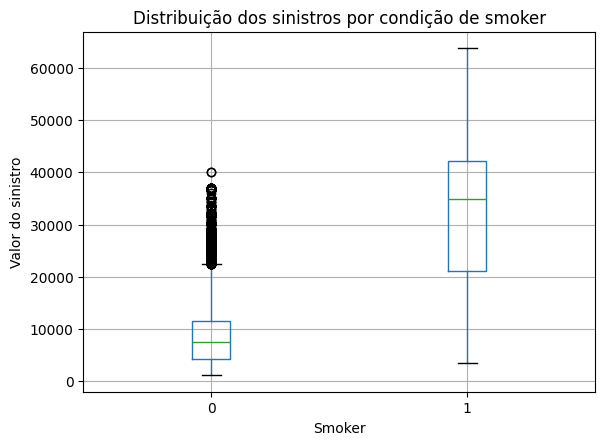

In [38]:
dados.boxplot(column="claim", by="smoker")

plt.xlabel("Smoker")
plt.ylabel("Valor do sinistro")
plt.title("Distribuição dos sinistros por condição de smoker")
plt.suptitle("")
plt.show()

### 2.1 Análise inicial da variável resposta `claim`

A variável `claim`, que representa o valor do sinistro e constitui a variável resposta do problema preditivo, apresentou média de aproximadamente 13.401,44 e mediana de 9.545,65, com valores variando entre 1.121,90 e 63.770,40.

O histograma evidenciou uma distribuição assimétrica à direita, resultado confirmado pelo coeficiente de assimetria de aproximadamente 1,50. Essa característica indica maior concentração de observações em valores menores de sinistro e a existência de uma cauda formada por valores mais elevados.

Pelo critério do intervalo interquartil (IQR), foram identificadas 1.642 observações acima do limite superior de 34.027,46, correspondendo a aproximadamente 10,95% da base. Esses registros foram considerados potenciais valores extremos para fins exploratórios, não implicando sua exclusão automática da análise.

### 2.2 Relação inicial entre `smoker` e `claim`

A análise exploratória revelou diferença expressiva no valor dos sinistros entre as categorias da variável `smoker`. Para os registros com `smoker = 0`, o valor médio do sinistro foi de aproximadamente 8.731,30 e a mediana de 7.512,30. Para `smoker = 1`, a média foi de aproximadamente 32.301,99 e a mediana de 34.838,90.

Entre as 1.642 observações classificadas como potenciais valores extremos pelo critério do IQR aplicado à distribuição geral de `claim`, 1.594 (97,08%) apresentam `smoker = 1`.

O boxplot de `claim` segundo `smoker` evidencia que os dois grupos apresentam distribuições bastante distintas. Dessa forma, os valores elevados observados na distribuição geral não devem ser interpretados automaticamente como erros ou observações inadequadas, pois parte deles parece estar associada às características de determinados grupos da carteira.

Os resultados constituem evidências exploratórias de associação entre `smoker` e o valor do sinistro. Nesta etapa, não se estabelece relação causal, e a relevância preditiva da variável deverá ser posteriormente avaliada durante a modelagem.